In [1]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, hinge_loss, log_loss
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [2]:
#Loading the datasets
df1 = pd.read_csv('DiaBD A Diabetes Dataset for Enhanced Risk Analysis\DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv')      # DiaBD dataset
df2 = pd.read_csv('DiaBD A Diabetes Dataset for Enhanced Risk Analysis\Type2_Diabetes_Dataset.csv')      # Clinical dataset

# DiaBD
df1 = df1.rename(columns={
    'age': 'Age',
    'bmi': 'BMI',
    'systolic_bp': 'BP_systolic',
    'diastolic_bp': 'BP_diastolic',
    'glucose': 'Glucose',
    'diabetic': 'Outcome'
})

# Type-2 Clinical dataset
df2 = df2.rename(columns={
    'No. of Pregnancy': 'Pregnancies',
    'Age': 'Age',
    'BMI': 'BMI',
    'BP(Systolic)': 'BP_systolic',
    'BP(Diastolic)': 'BP_diastolic',
    'DiabetesPedigreeFunction': 'DiabetesPedigreeFunction',
    'Insulin': 'Insulin',
    'Skin Thickness(mm)': 'SkinThickness',
    'Glucose': 'Glucose',
    'Outcome': 'Outcome'
})

# Mapping the 'Outcome' column to binary values
df1['Outcome'] = df1['Outcome'].map({'Yes': 1, 'No': 0})
df2['Outcome'] = df2['Outcome'].map({1: 1, 0: 0})

# Handling missing values in df1 by filling them with random values within a reasonable range
df1['Pregnancies'] = np.random.randint(1, 9, size=len(df1))
df1['Insulin'] = np.random.uniform(1, 14, size=len(df1))
df1['SkinThickness'] = np.random.uniform(10, 50, size=len(df1))
df1['DiabetesPedigreeFunction'] = np.random.uniform(0.1, 2.5, size=len(df1))

# Reordering columns in df1 to match df2
df1 = df1[[
    'Pregnancies', 'Age', 'BMI',
    'BP_systolic', 'BP_diastolic',
    'DiabetesPedigreeFunction',
    'Insulin', 'SkinThickness',
    'Glucose', 'Outcome'
]]

# Reorder columns in df2 to match df1, selecting only columns that exist
df2 = df2[[
    'Pregnancies', 'Age', 'BMI',
    'BP_systolic', 'BP_diastolic',
    'DiabetesPedigreeFunction',
    'Insulin', 'SkinThickness',
    'Glucose', 'Outcome'
]]


In [3]:
# Handling missing values in df1 and df2 by replacing 0 with NaN for specific columns
cols = ['BMI', 'BP_systolic', 'BP_diastolic', 'Insulin', 'SkinThickness', 'Glucose']

for col in cols:
    df1[col] = df1[col].replace(0, np.nan)
    df2[col] = df2[col].replace(0, np.nan)

# Filling missing values with median for both datasets
for col in cols:
    df1[col].fillna(df1[col].median(), inplace=True)
    df2[col].fillna(df2[col].median(), inplace=True)

df1['DiabetesPedigreeFunction'].fillna(0.5, inplace=True)
df2['DiabetesPedigreeFunction'].fillna(df2['DiabetesPedigreeFunction'].median(), inplace=True)


0      0
1      2
2      0
3      0
4      0
      ..
460    2
461    0
462    0
463    0
464    2
Name: DiabetesPedigreeFunction, Length: 465, dtype: int64

In [4]:
# Displaying information about the datasets
df1.info()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               5288 non-null   int32  
 1   Age                       5288 non-null   int64  
 2   BMI                       5288 non-null   float64
 3   BP_systolic               5288 non-null   int64  
 4   BP_diastolic              5288 non-null   int64  
 5   DiabetesPedigreeFunction  5288 non-null   float64
 6   Insulin                   5288 non-null   float64
 7   SkinThickness             5288 non-null   float64
 8   Glucose                   5287 non-null   float64
 9   Outcome                   5288 non-null   int64  
dtypes: float64(5), int32(1), int64(4)
memory usage: 392.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --

In [5]:
# Merging the datasets
merged_df = pd.concat([df1, df2], ignore_index=True)

# Handling missing values in the merged dataset by filling them with median values
merged_df['Glucose'].fillna(merged_df['Glucose'].median(), inplace=True)
merged_df['Insulin'].fillna(merged_df['Insulin'].median(), inplace=True)
merged_df['SkinThickness'].fillna(merged_df['SkinThickness'].median(), inplace=True)

# Removing duplicates and resetting index
merged_df.drop_duplicates(inplace=True)
merged_df.reset_index(drop=True, inplace=True)

merged_df['Glucose'] = merged_df['Glucose'].round()
merged_df['Insulin'] = merged_df['Insulin'].round()
merged_df['SkinThickness'] = merged_df['SkinThickness'].round()

merged_df['Glucose'] = merged_df['Glucose'].fillna(merged_df['Glucose'].median()).astype('int64')
merged_df['Insulin'] = merged_df['Insulin'].fillna(merged_df['Insulin'].median()).astype('int64')
merged_df['SkinThickness'] = merged_df['SkinThickness'].fillna(merged_df['SkinThickness'].median()).astype('int64')

# Saving the merged dataset to a new CSV file
merged_df.to_csv("final_diabetes_dataset.csv", index=False)

In [6]:
merged_df.info()
merged_df['Outcome'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               5752 non-null   int64  
 1   Age                       5752 non-null   int64  
 2   BMI                       5752 non-null   float64
 3   BP_systolic               5752 non-null   int64  
 4   BP_diastolic              5752 non-null   int64  
 5   DiabetesPedigreeFunction  5752 non-null   float64
 6   Insulin                   5752 non-null   int64  
 7   SkinThickness             5752 non-null   int64  
 8   Glucose                   5752 non-null   int64  
 9   Outcome                   5752 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 449.5 KB


Outcome
0    5038
1     714
Name: count, dtype: int64

In [7]:
# Separating the majority and minority classes
df_majority = merged_df[merged_df['Outcome'] == 0]
df_minority = merged_df[merged_df['Outcome'] == 1]

# Downsampling the majority class to some extent to balance the dataset
df_majority_downsampled = df_majority.sample(
    n=1931,
    random_state=42
)

# Combining the downsampled majority class with the minority class
balanced_df = pd.concat([df_majority_downsampled, df_minority])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Checking the class distribution in the balanced dataset
print(balanced_df['Outcome'].value_counts())

# percentage check
counts = balanced_df['Outcome'].value_counts(normalize=True) * 100
print(counts)


Outcome
0    1931
1     714
Name: count, dtype: int64
Outcome
0    73.005671
1    26.994329
Name: proportion, dtype: float64


In [8]:
# Saving the balanced dataset & updating the final dataset with the balanced data
merged_df = balanced_df.copy()
merged_df.to_csv("final_diabetes_dataset.csv", index=False)

In [9]:
# Loading the final dataset and checking the class distribution
final_df = pd.read_csv("final_diabetes_dataset.csv")
final_df['Outcome'].value_counts()

Outcome
0    1931
1     714
Name: count, dtype: int64

In [10]:
final_df.head()

,Pregnancies,Age,BMI,BP_systolic,BP_diastolic,DiabetesPedigreeFunction,Insulin,SkinThickness,Glucose,Outcome
0,7,25,16.790000,111,73,1.645713,2,20,6,0
1,2,37,23.822169,90,60,1.000000,8,356,100,1
2,5,52,24.340000,152,100,0.624165,13,31,15,0
3,6,40,31.430000,141,79,1.539293,8,25,10,0
4,6,40,22.060000,173,107,2.308249,9,48,7,0


In [11]:
final_df.shape

(2645, 10)

In [12]:
final_df.describe()

,Pregnancies,Age,BMI,BP_systolic,BP_diastolic,DiabetesPedigreeFunction,Insulin,SkinThickness,Glucose,Outcome
count,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000
mean,4.276371,45.797732,22.900281,132.705860,82.218904,1.374205,8.097543,72.536106,29.318336,0.269943
std,2.278706,13.158305,4.137895,22.089088,12.263593,0.918181,4.457092,101.575788,56.321169,0.444014
min,0.000000,21.000000,13.310000,62.000000,30.000000,0.000000,1.000000,10.000000,0.000000,0.000000
25%,2.000000,35.000000,20.190000,119.000000,74.000000,0.675877,5.000000,22.000000,6.000000,0.000000
50%,4.000000,45.000000,22.390000,129.000000,80.000000,1.354947,8.000000,34.000000,7.000000,0.000000
75%,6.000000,55.000000,25.150000,145.000000,90.000000,2.000000,11.000000,46.000000,11.000000,1.000000
max,12.000000,86.000000,47.970000,231.000000,120.000000,8.000000,44.000000,406.000000,450.000000,1.000000


In [13]:
final_df.groupby('Outcome').mean()

,Pregnancies,Age,BMI,BP_systolic,BP_diastolic,DiabetesPedigreeFunction,Insulin,SkinThickness,Glucose
Outcome,,,,,,,,,
0,4.443294,45.196271,22.284527,132.611600,81.403936,1.350628,7.507509,34.296220,8.229415
1,3.824930,47.424370,24.565577,132.960784,84.422969,1.437969,9.693277,175.955182,86.352941


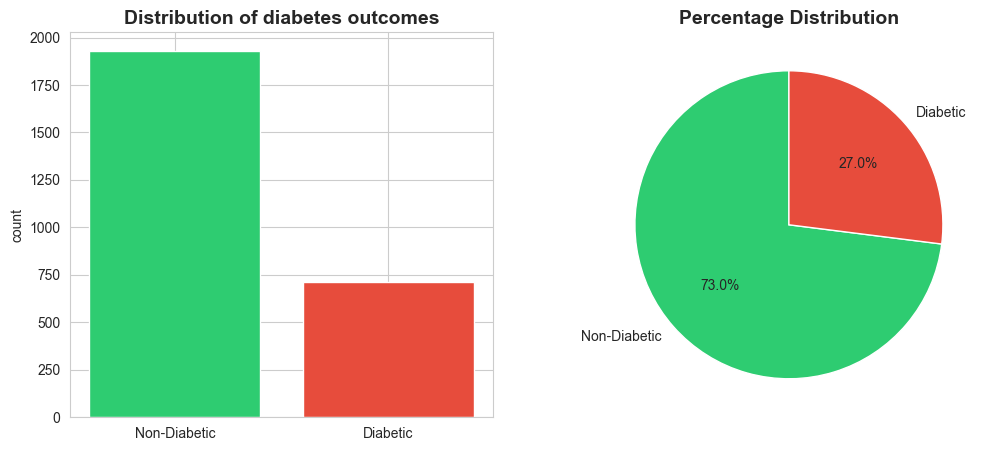

In [14]:
# Visualizing the class distribution
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
outcome_counts = final_df['Outcome'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, color=['#2ecc71','#e74c3c'])
plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')

plt.subplot(1,2,2)
plt.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Percentage Distribution', fontsize=14, fontweight='bold')
plt.show()

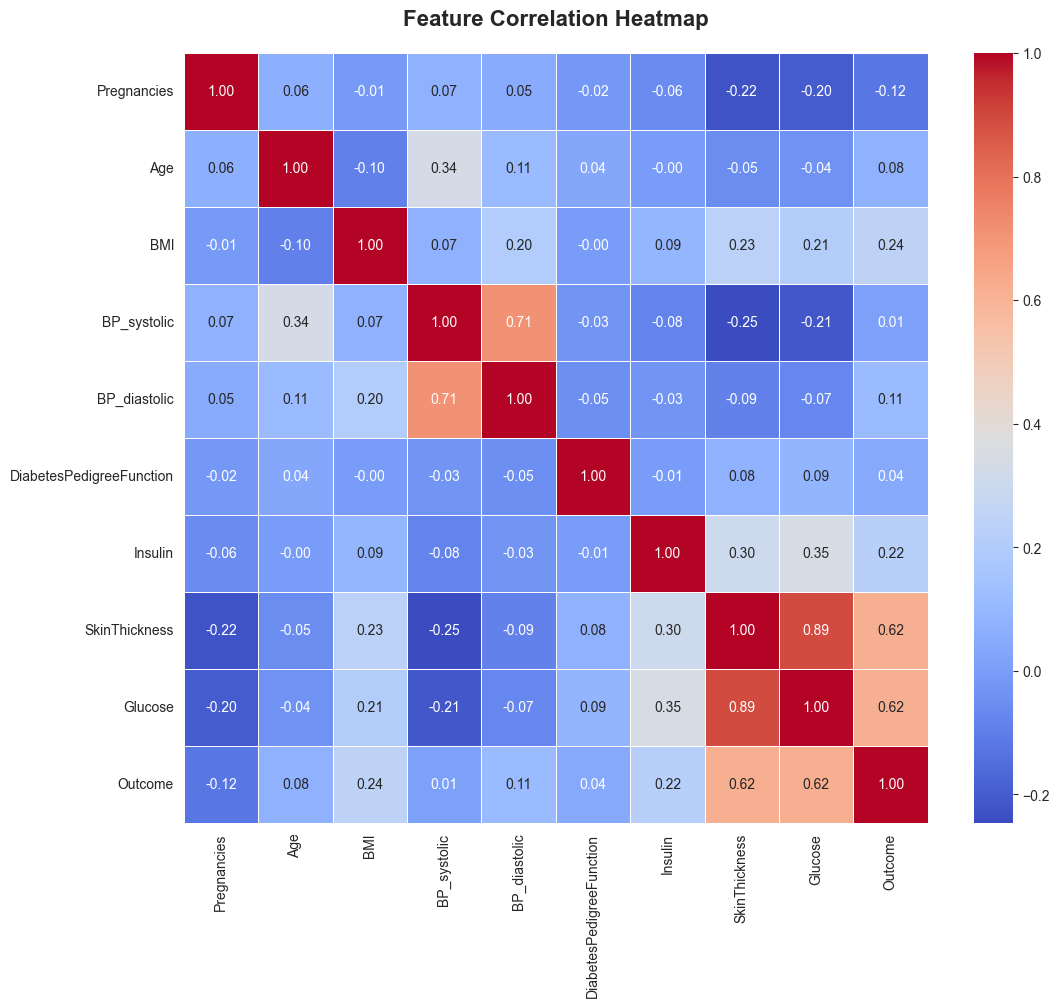

In [15]:
# Visualizing the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(final_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20, fontweight='bold')
plt.show()

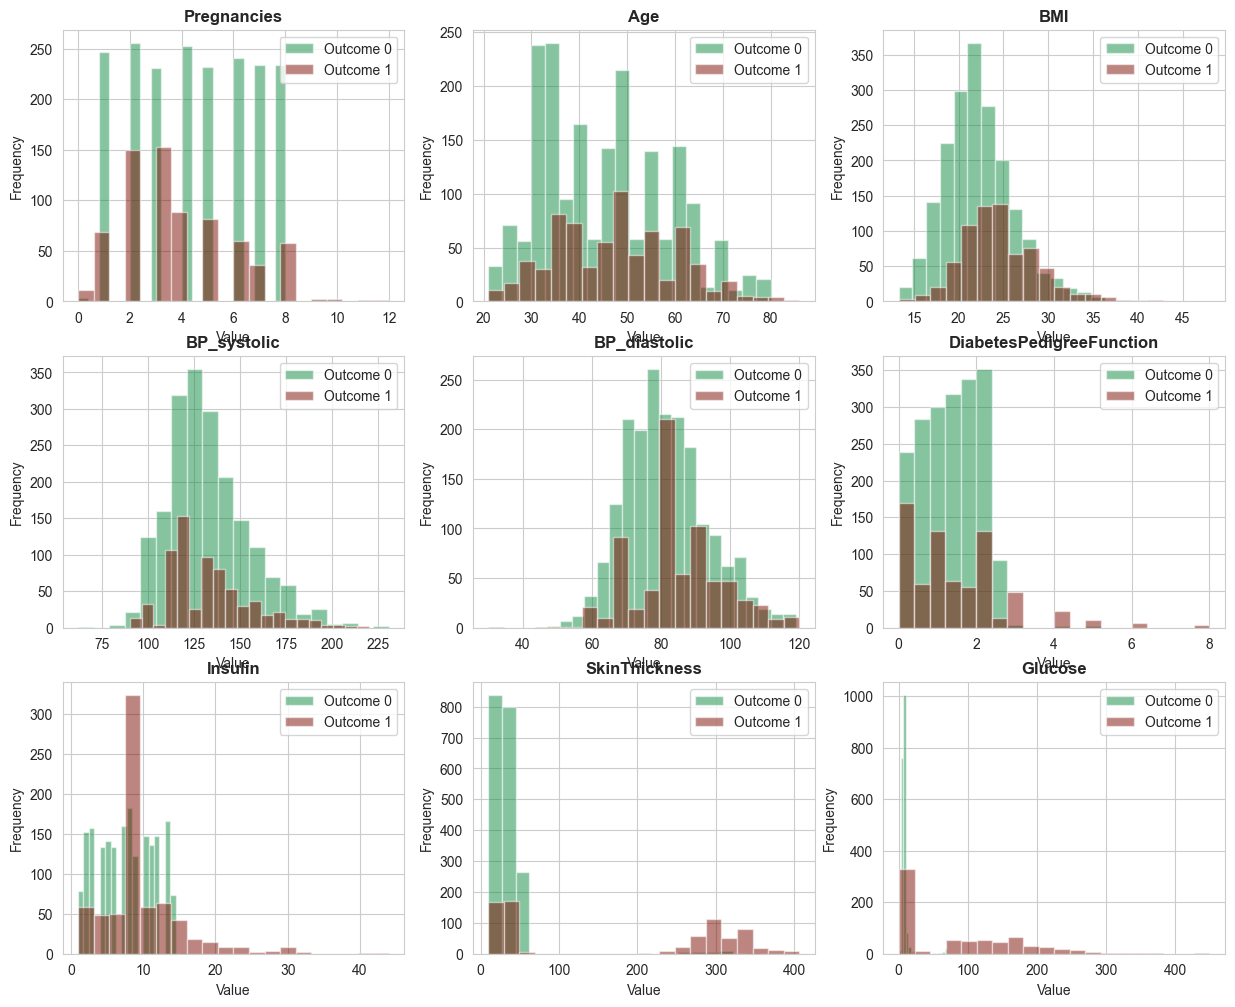

In [16]:
# Visualizing the distribution of features for diabetic vs non-diabetic outcomes
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
features = final_df.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    for outcome in [0,1]:  
        data = final_df[final_df['Outcome'] == outcome][feature]
        axes[row, col].hist(data, alpha=0.5, label=f'Outcome {outcome}', bins=20, 
                            color=["#0f8a42", "#7a0c00"][outcome])
        axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].legend()
plt.show()

In [17]:
# Preparing the data for modeling
X = final_df.drop('Outcome', axis=1)
y = final_df['Outcome']

print(X)
print(y)

      Pregnancies  Age        BMI  BP_systolic  BP_diastolic  \
0               7   25  16.790000          111            73   
1               2   37  23.822169           90            60   
2               5   52  24.340000          152           100   
3               6   40  31.430000          141            79   
4               6   40  22.060000          173           107   
...           ...  ...        ...          ...           ...   
2640            5   35  25.410000          140            90   
2641            1   36  20.700000          128            83   
2642            2   60  15.550000          170            92   
2643            7   30  20.710000          127            74   
2644            3   65  20.610000          114            71   

      DiabetesPedigreeFunction  Insulin  SkinThickness  Glucose  
0                     1.645713        2             20        6  
1                     1.000000        8            356      100  
2                     0.624165   

In [18]:
# Scaling the features and standardizing the data to improve model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.19547869, -1.58087717, -1.47694332, ..., -1.36831262,
        -0.51730871, -0.41410265],
       [-0.99916396, -0.66873317,  0.22283369, ..., -0.02188893,
         2.79119169,  1.25521237],
       [ 0.31762163,  0.47144683,  0.34800091, ...,  1.10013081,
        -0.40899471, -0.25427462],
       ...,
       [-0.99916396,  1.07954283, -1.77666926, ..., -0.47069683,
        -0.23175362, -0.39634398],
       [ 1.19547869, -1.20081717, -0.52942261, ..., -1.14390867,
        -0.2612938 , -0.41410265],
       [-0.56023543,  1.45960283, -0.55359406, ..., -0.24629288,
        -0.50746199, -0.41410265]], shape=(2645, 9))

In [19]:
# Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=25)
print(X.shape, x_train.shape, x_test.shape)

(2645, 9) (1851, 9) (794, 9)


__Support Vector Machine(SVM)__

In [20]:
# Training the Support Vector Machine (SVM) model
classifier = svm.SVC(kernel='linear', random_state=32, class_weight='balanced', probability=True)
classifier.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
x_train_pred = classifier.predict(x_train)
training_accuracy = accuracy_score(x_train_pred,y_train)
training_accuracy

0.8676391139924365

In [22]:
# Testing the model
x_test_pred = classifier.predict(x_test)
testing_accuracy_svm = accuracy_score(x_test_pred,y_test)
testing_accuracy_svm

# Transform test data
X_test_scaled = scaler.transform(x_test)

In [23]:
# Evaluating SVM model using precision, recall, and F1-score
precision = precision_score(y_test, x_test_pred)
recall = recall_score(y_test, x_test_pred)
f1 = f1_score(y_test, x_test_pred)

print(f"Precision of SVM: {precision:.2f}")
print(f"Recall of SVM: {recall:.2f}")
print(f"F1-Score of SVM: {f1:.2f}")

Precision of SVM: 0.74
Recall of SVM: 0.68
F1-Score of SVM: 0.71


In [24]:
# Predictions from SVM
y_scores = classifier.decision_function(x_test)

# Hinge loss calculation
svm_loss = hinge_loss(y_test, y_scores)

print("SVM Hinge Loss:", svm_loss)

#Log loss calculation
y_prob = classifier.predict_proba(x_test)
svm_log_loss = log_loss(y_test, y_prob)
print("SVM Log Loss:", svm_log_loss)

SVM Hinge Loss: 0.34875279018848043
SVM Log Loss: 0.3073951076687609


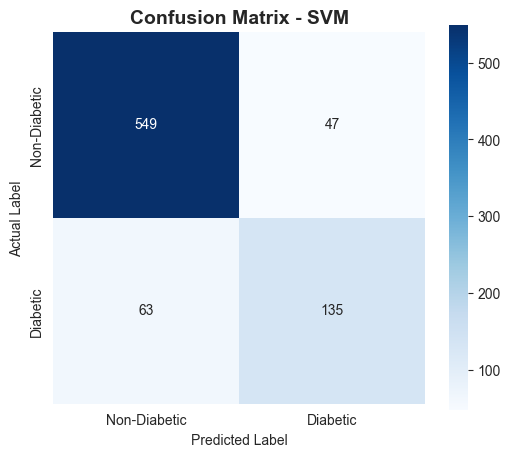

In [25]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, x_test_pred)
cm_svm

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', square=True, 
            xticklabels=['Non-Diabetic', 'Diabetic'], 
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()


**Random Forest Model**

In [26]:
# Training the Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, 
    random_state=32, 
    class_weight='balanced', 
    min_samples_split=5, 
    min_samples_leaf=2)
rf_classifier.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [27]:
x_train_pred_rf = rf_classifier.predict(x_train)
training_accuracy_rf = accuracy_score(y_train, x_train_pred_rf)
training_accuracy_rf

0.9632631010264722

In [28]:
# Testing the Random Forest model
x_test_pred_rf = rf_classifier.predict(x_test)
testing_accuracy_rf = accuracy_score(y_test, x_test_pred_rf)
testing_accuracy_rf

0.889168765743073

In [29]:
#Evaluating the Random Forest model
precision_rf = precision_score(y_test, x_test_pred_rf)
recall_rf = recall_score(y_test, x_test_pred_rf)
f1_rf = f1_score(y_test, x_test_pred_rf)
print(f"Precision of Random Forest: {precision_rf:.2f}")
print(f"Recall of Random Forest: {recall_rf:.2f}")
print(f"F1-Score of Random Forest: {f1_rf:.2f}")

Precision of Random Forest: 0.82
Recall of Random Forest: 0.71
F1-Score of Random Forest: 0.76


In [30]:
# Probabilities
y_prob = rf_classifier.predict_proba(x_test)

# Log loss calculation
rf_loss = log_loss(y_test, y_prob)

print("Random Forest Log Loss:", rf_loss)

Random Forest Log Loss: 0.2923093962627496


In [31]:
cm_rf = confusion_matrix(y_test, x_test_pred_rf)
cm_rf

array([[566,  30],
       [ 58, 140]])

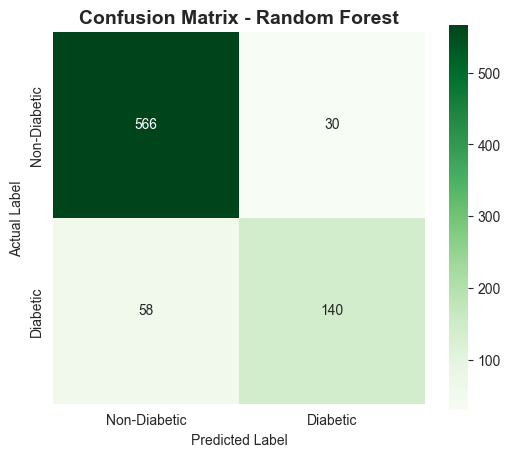

In [32]:
# Visualizing the confusion matrix for Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [33]:
# Comparing the accuracies of the three models
print("SVM Accuracy:", testing_accuracy_svm)
print("Random Forest Accuracy:", testing_accuracy_rf)

if testing_accuracy_rf > testing_accuracy_svm :
    print("Random Forest performs better.")
else:
    print("SVM performs better.")


SVM Accuracy: 0.8614609571788413
Random Forest Accuracy: 0.889168765743073
Random Forest performs better.


In [34]:
#Comparison based on loss values of SVM and Random Forest for diabetes risk prediction
if rf_loss < svm_log_loss:
    print("Random Forest is more suitable for diabetes risk prediction due to its lower loss value.")

else:
    print("SVM is more suitable for diabetes risk prediction due to its lower loss value.")

#Comparing the hinge loss value of SVM
if svm_loss < 0.5:
    print("Excellent class separation and prediction performance.")
    
elif svm_loss < 1.0:
    print("Good classification performance with acceptable margin separation.")
    
elif svm_loss < 2.0:
    print("Moderate classification performance with some overlap between classes.")
    
else:
    print("Poor classification performance. Model may be underfitting or misclassifying samples.")

Random Forest is more suitable for diabetes risk prediction due to its lower loss value.
Excellent class separation and prediction performance.


In [35]:
import joblib

joblib.dump(rf_classifier, 'diabetes_model.pkl') # pyright: ignore[reportUndefinedVariable]
joblib.dump(scaler, 'scaler_svm.pkl') # pyright: ignore[reportUndefinedVariable]

['scaler_svm.pkl']

In [ ]:
# Make a prediction for a new data point
input_data =(1, 21, 22.5, 110, 70, 0.1, 13, 25, 35)
input_num_array = np.array(input_data).reshape(1, -1)

input_data_scaled = scaler.transform(input_num_array)
prediction = rf_classifier.predict(input_data_scaled)

if prediction[0] == 1:
    print("The person is likely to have diabetes.")
else:
    print("The person is unlikely to have diabetes.")


The person is likely to have diabetes.
